In [53]:
import pandas as pd 
import numpy as np 
import math 

import seaborn as sns 
import missingno 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D 
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import plotly.express as px 
import phik 
from pygeodesy import GeoidKarney, LatLon_ 

from sklearn.model_selection import train_test_split, KFold 
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.ensemble import StackingRegressor 
from sklearn.linear_model import Ridge 
from sklearn.svm import SVR 
from sklearn.neighbors import NearestNeighbors 

from catboost import CatBoostRegressor, Pool 
from xgboost import XGBRegressor 
import optuna 
import joblib 

import warnings 
warnings.filterwarnings("ignore") 

# Исправленные функции для условия Лапласса

In [54]:
def improved_laplacian_constraint(y_pred, coordinates, h=0.1):
    """
    Улучшенное вычисление лапласиана с использованием k-NN
    """
    # Преобразуем в float32 для совместимости с линейной алгеброй
    coords = np.array(coordinates, dtype=np.float32)
    y_pred = np.array(y_pred, dtype=np.float32)
    
    n_neighbors = 6  # Минимум 6 соседей для 3D лапласиана
    
    # Поиск ближайших соседей
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    laplacian = np.zeros(len(y_pred), dtype=np.float32)
    
    for i in range(len(y_pred)):
        # Пропускаем саму точку (первый индекс)
        neighbor_indices = indices[i][1:]
        
        if len(neighbor_indices) >= 6:
            # Координаты соседей
            neighbor_coords = coords[neighbor_indices]
            neighbor_vals = y_pred[neighbor_indices]
            
            # Центрирование координат
            center_coord = coords[i]
            centered_coords = neighbor_coords - center_coord
            
            # Решение системы для вторых производных
            try:
                # Матрица гессиана
                A = centered_coords
                b = neighbor_vals - y_pred[i]
                
                # Решение методом наименьших квадратов
                derivatives, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
                
                # Лапласиан - след гессиана
                laplacian[i] = np.sum(derivatives[:3])  # Первые три производные
                
            except np.linalg.LinAlgError:
                laplacian[i] = 0
        else:
            laplacian[i] = 0
    
    return laplacian

class ImprovedLaplaceLoss:
    def __init__(self, coordinates, alpha=0.01, beta=0.001):
        self.coordinates = coordinates
        self.alpha = alpha  # Вес лапласиана
        self.beta = beta    # Вес градиента
        
    def __call__(self, y_true, y_pred):
        # Основная MSE
        mse_loss = np.mean((y_true - y_pred) ** 2)
        
        # Условие Лапласса
        laplacian = improved_laplacian_constraint(y_pred, self.coordinates)
        laplace_loss = np.mean(laplacian ** 2)
        
        # Условие на градиент
        grad_loss = self.calculate_gradient_constraint(y_pred, self.coordinates)
        
        total_loss = mse_loss + self.alpha * laplace_loss + self.beta * grad_loss
        
        return total_loss
    
    def calculate_gradient_constraint(self, y_pred, coordinates):
        """Регуляризация на гладкость градиента"""
        nbrs = NearestNeighbors(n_neighbors=2).fit(coordinates)
        distances, indices = nbrs.kneighbors(coordinates)
        
        grad_variation = 0
        count = 0
        
        for i in range(len(y_pred)):
            if distances[i][1] > 0:  # Есть хотя бы один сосед
                j = indices[i][1]
                grad_ij = (y_pred[i] - y_pred[j]) / distances[i][1]
                grad_variation += grad_ij ** 2
                count += 1
        
        return grad_variation / count if count > 0 else 0

# Упрощенная версия обучения (без оптимизации гиперпараметров)

In [55]:
def simple_train(X, y):
    """Упрощенный пайплайн обучения"""
    
    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=CFG.RANDOM_STATE, shuffle=True
    )
    
    # Масштабирование признаков
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Подготовка координат
    coord_cols = ['Latitude (deg)', 'Longitude (deg)', 'Height (m)']
    train_coords = X_train[coord_cols].values.astype(np.float32)  # Преобразуем в float32
    test_coords = X_test[coord_cols].values.astype(np.float32)    # Преобразуем в float32
    
    # Создание модели
    model = CatBoostRegressor(
        iterations=100000,
        learning_rate=0.01,
        depth=7,
        l2_leaf_reg=7,
        loss_function='RMSE',
        random_seed=CFG.RANDOM_STATE,
        verbose=1000,
        task_type='CPU',
        early_stopping_rounds=100
    )
    
    # Обучение модели
    print("Начало обучения модели...")
    model.fit(
        X_train_scaled, y_train.values.flatten(),
        eval_set=(X_test_scaled, y_test.values.flatten()),
        verbose=1000
    )
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Оценка модели
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f" MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R²: {r2:.6f}")
    
    # Проверка условия Лапласса
    laplacian = improved_laplacian_constraint(y_pred, test_coords)
    laplace_error = np.mean(laplacian ** 2)
    print(f"Laplace constraint error: {laplace_error:.6f}")
    
    # Визуализации
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min().values[0], y_test.max().values[0]], 
             [y_test.min().values[0], y_test.max().values[0]], 'r--', lw=2)
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказания')
    plt.title('Истинные vs Предсказанные значения')
    
    plt.subplot(1, 3, 2)
    residuals = y_test.values.flatten() - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Остатки vs Предсказания')
    
    plt.subplot(1, 3, 3)
    plt.hist(residuals, bins=50, alpha=0.7)
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.title('Распределение остатков')
    
    plt.tight_layout()
    plt.show()
    
    # Важность признаков
    feature_importance = model.get_feature_importance()
    feature_names = X.columns.tolist()
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=importance_df.head(15))
    plt.title('Топ-15 важных признаков')
    plt.tight_layout()
    plt.show()
    
    return model, scaler, {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'laplace_error': laplace_error
    }

# Запуск упрощенной версии

In [56]:
def run_simple_pipeline():
    """Запуск упрощенного пайплайна"""
    
    # Загрузка и подготовка данных
    print("=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===")
    loader = AdvancedDataLoader(CFG.COLORADO_PATH, CFG.NSO_PATH)
    X, y = loader.load_and_preprocess('colorado')
    
    # Обучение модели
    print("\n=== ОБУЧЕНИЕ МОДЕЛИ ===")
    model, scaler, results = simple_train(X, y)
    
    # Сохранение модели
    joblib.dump({'model': model, 'scaler': scaler}, 'simple_gravity_model.joblib')
    print("Модель сохранена как 'simple_gravity_model.joblib'")
    
    # Дополнительная валидация на всем датасете
    print("\n=== ВАЛИДАЦИЯ НА ВСЕМ ДАТАСЕТЕ ===")
    
    X_scaled = scaler.transform(X)
    all_predictions = model.predict(X_scaled)
    
    coords = X[['Latitude (deg)', 'Longitude (deg)', 'Height (m)']].values
    
    full_mse = mean_squared_error(y, all_predictions)
    full_rmse = np.sqrt(full_mse)
    full_mae = mean_absolute_error(y, all_predictions)
    full_r2 = r2_score(y, all_predictions)
    
    laplacian = improved_laplacian_constraint(all_predictions, coords)
    laplace_error = np.mean(laplacian ** 2)
    
    print("\n=== РЕЗУЛЬТАТЫ НА ВСЕМ ДАТАСЕТЕ ===")
    print(f"MSE: {full_mse:.6f}")
    print(f"RMSE: {full_rmse:.6f}")
    print(f"MAE: {full_mae:.6f}")
    print(f"R²: {full_r2:.6f}")
    print(f"Laplace constraint error: {laplace_error:.6f}")
    
    return model, scaler, results

=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Загрузка данных: colorado
Изначальное использование памяти: 0.67 MB
Итоговое использование памяти: 0.20 MB
Экономия 70.4%

=== АНАЛИЗ ДАННЫХ ===
Размер датасета: (4608, 19)

Пропущенные значения:
Latitude (deg)        0
Longitude (deg)       0
Height (m)            0
Height relief (m)     0
Height geoid (m)      0
GGFM_f                0
x                     0
y                     0
z                     0
distance_to_center    0
geoid_height          0
lat_lon_product       0
height_squared        0
sin_lat               0
cos_lat               0
sin_lon               0
cos_lon               0
lat_height            0
lon_height            0
dtype: int64

Статистика целевой переменной:
             GGFM_f
count  4.608000e+03
mean   6.237893e+07
std    1.480706e+04
min    6.234922e+07
25%    6.236742e+07
50%    6.237762e+07
75%    6.239046e+07
max    6.241534e+07


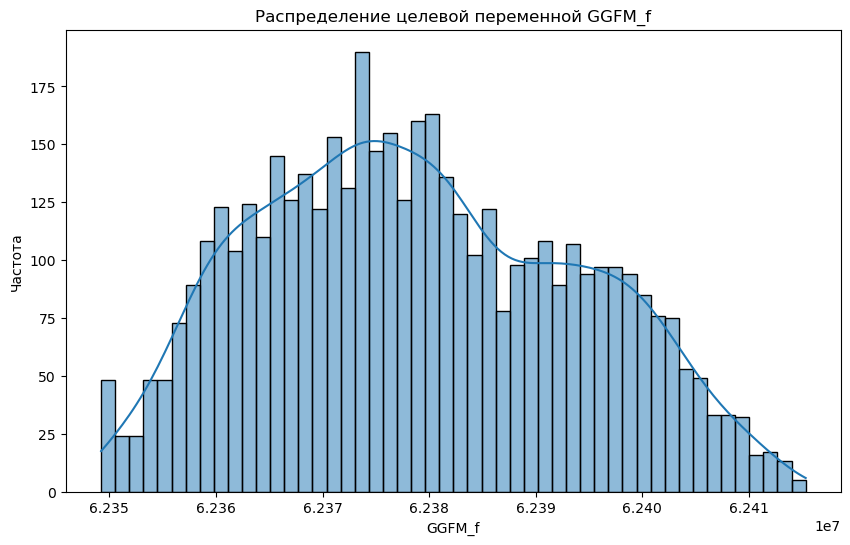

Выбросы в целевой переменной: 0


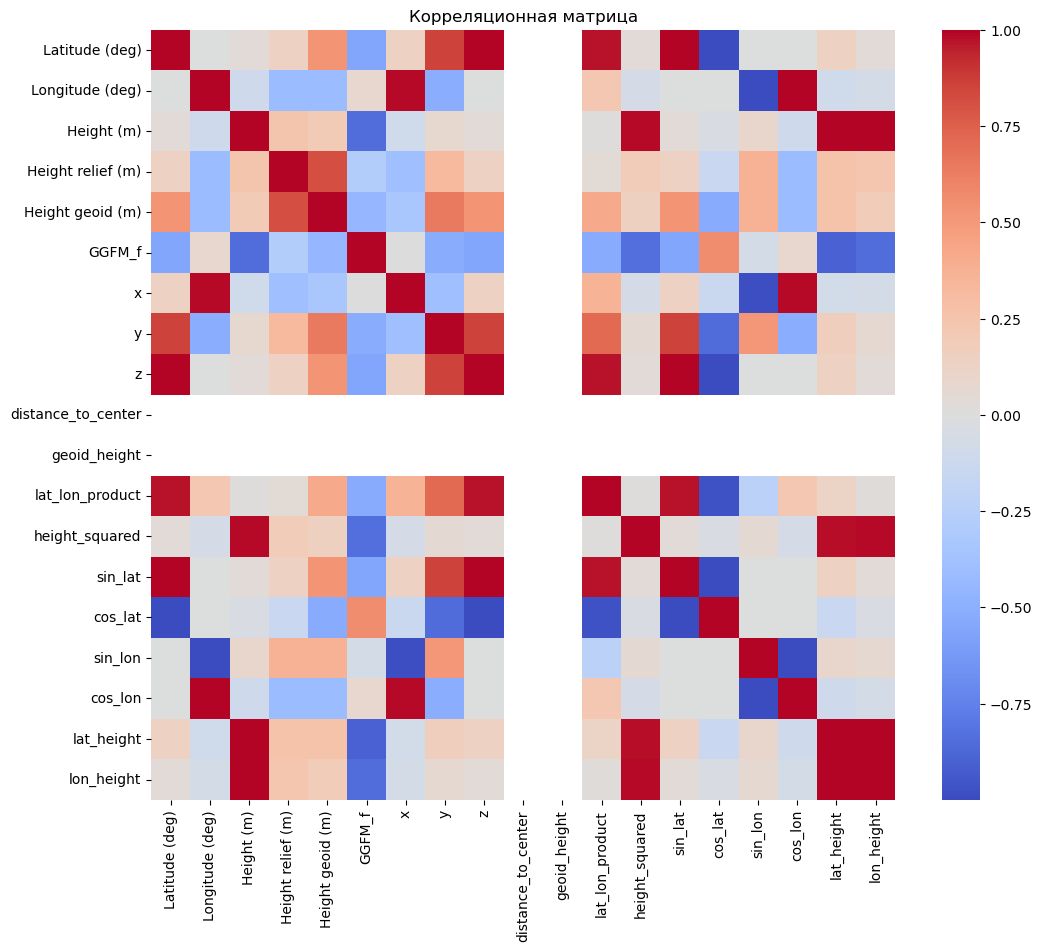


=== ОБУЧЕНИЕ МОДЕЛИ ===
Начало обучения модели...
0:	learn: 14666.0411574	test: 14724.8625753	best: 14724.8625753 (0)	total: 3.35ms	remaining: 5m 34s
1000:	learn: 212.4176028	test: 264.7871325	best: 264.7871325 (1000)	total: 2.24s	remaining: 3m 41s
2000:	learn: 127.2034151	test: 179.8847535	best: 179.8847535 (2000)	total: 4.25s	remaining: 3m 28s
3000:	learn: 94.2592785	test: 146.9118273	best: 146.9118273 (3000)	total: 6.22s	remaining: 3m 21s
4000:	learn: 75.8134712	test: 129.9803203	best: 129.9803203 (4000)	total: 8.15s	remaining: 3m 15s
5000:	learn: 64.5064850	test: 120.3679850	best: 120.3679850 (5000)	total: 10.1s	remaining: 3m 11s
6000:	learn: 56.4371810	test: 114.3544237	best: 114.3544237 (6000)	total: 12s	remaining: 3m 8s
7000:	learn: 50.3391716	test: 110.3026568	best: 110.3026568 (7000)	total: 13.9s	remaining: 3m 4s
8000:	learn: 45.6536509	test: 107.2765722	best: 107.2765722 (8000)	total: 16s	remaining: 3m 3s
9000:	learn: 41.7693332	test: 105.0099059	best: 105.0099059 (9000)	tot

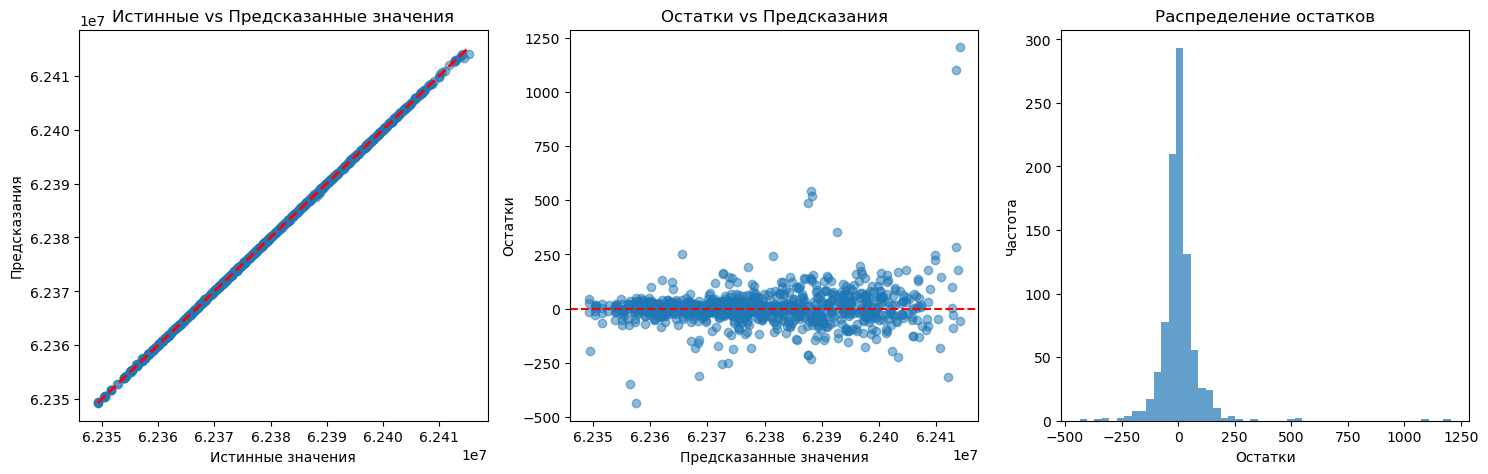

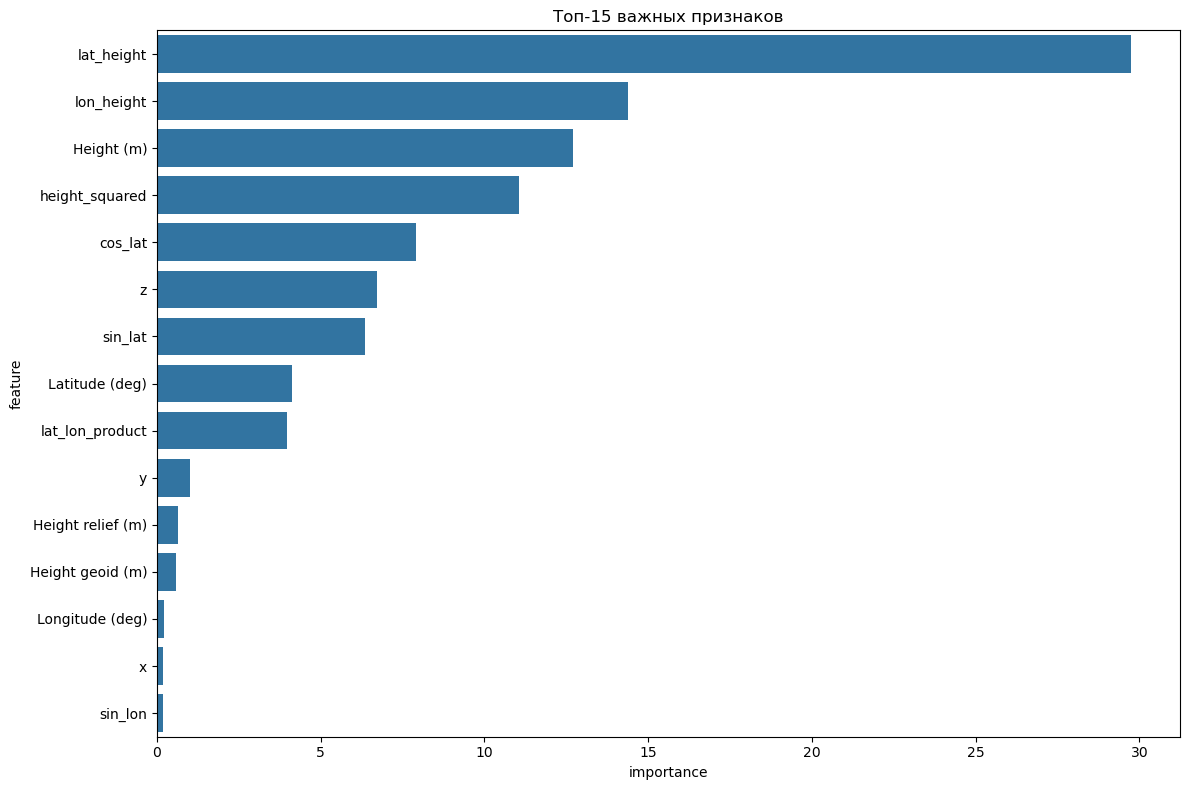

Модель сохранена как 'simple_gravity_model.joblib'

=== ВАЛИДАЦИЯ НА ВСЕМ ДАТАСЕТЕ ===

=== РЕЗУЛЬТАТЫ НА ВСЕМ ДАТАСЕТЕ ===
MSE: 1718.551635
RMSE: 41.455417
MAE: 14.174483
R²: 0.999992
Laplace constraint error: 27402296.000000


(<catboost.core.CatBoostRegressor at 0x10bfc6b0e80>,
 RobustScaler(),
 {'mse': 8396.636868411306,
  'rmse': 91.63316467530359,
  'mae': 49.14180387730292,
  'r2': 0.9999618484937566,
  'laplace_error': 27231536.0})

In [57]:
run_simple_pipeline()